In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from flax import nnx, serialization
import optax

from abc import ABC, abstractmethod

import matplotlib.pyplot as plt
from typing import Callable

jax.devices()

[CudaDevice(id=0)]

In [2]:
class ScatteringMLP(nnx.Module):
    def __init__(self, din, n_modes, n_out_channels, hidden_dims, rngs):
        self.din = din
        self.n_modes = n_modes
        self.n_out_channels = n_out_channels
        dims = [din] + hidden_dims + [n_modes * n_out_channels * 2]
        self.layers = nnx.List([
            nnx.Linear(dims[i], dims[i + 1], rngs=rngs)
            for i in range(len(dims) - 1)
        ])

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
            x = nnx.gelu(x)
        x = x.reshape(-1, 2 * self.n_modes, self.n_out_channels)
        x = x[..., :self.n_modes, :] + 1j * x[..., self.n_modes:, :]
        return x

In [49]:
color = 'blue'
n_propagating = 61

data = np.load('rgb_cylindrical.npz')
params = data['params']
amps = data[f'amps_{color[0]}'].reshape(-1, 4, n_propagating).transpose(0, 2, 1)

print(params.shape, params.dtype)
print(amps.shape, amps.dtype)

(8320, 3) float32
(8320, 61, 4) complex64


In [50]:
n_train = 2 ** 13
n_val = 128
print(len(params), n_train + n_val)

x_train = params[:n_train]
y_train = amps[:n_train]
x_val = params[n_train:n_train + n_val]
y_val = amps[n_train:n_train + n_val]

data_variance = jnp.mean(jnp.var(y_train.reshape(y_train.shape[0], -1), axis=-1))
print('Dataset variance:', data_variance)
print('Validation set variance', jnp.mean(jnp.var(y_val.reshape(y_val.shape[0], -1), axis=-1)))

8320 8320
Dataset variance: 0.0042904234
Validation set variance 0.0042803986


In [51]:
rngs = nnx.Rngs(42)
model = ScatteringMLP(din=3, n_modes=n_propagating, n_out_channels=4, hidden_dims=[256] * 6, rngs=rngs)

min_loss = 1000
best_state = None

x = x_train[:2]
print(x.shape)
y = model(x)
print(y.shape, y.dtype)

@nnx.jit
def train_step(model, optimizer, x, y):
    def loss_fn(model):
        y_pred = model(x)
        return jnp.mean(jnp.abs(y_pred - y) ** 2)

    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(model, grads)
    return loss

@nnx.jit
def validate_loss(model, x, y):
    y_pred = model(x)
    return jnp.mean(jnp.abs(y_pred - y) ** 2)

train_loss_history = []
val_loss_history = []

(2, 3)
(2, 61, 4) complex64


In [52]:
batch_size = 32
n_batches = n_train // batch_size
n_epochs = 400

optimizer = nnx.Optimizer(model, optax.adam(learning_rate=5e-4), wrt=nnx.Param)

for epoch in range(n_epochs):
    data_permutation = jax.random.permutation(rngs(), len(x_train))
    for i in range(n_batches):
        batch_start_index = i * batch_size
        batch_end_index = batch_start_index + batch_size
        x = x_train[data_permutation[batch_start_index:batch_end_index]]
        y = y_train[data_permutation[batch_start_index:batch_end_index]]
        current_loss = train_step(model, optimizer, x, y)

        if i % 128 == 0:
            val_loss = validate_loss(model, x_val, y_val)
            samples_processed = (epoch * n_batches + i) * batch_size
            print(samples_processed, current_loss, val_loss)
            train_loss_history.append(current_loss)
            val_loss_history.append(val_loss)

            if val_loss < min_loss:
                min_loss = val_loss
                state = nnx.state(model)
                best_state = state
                state_dict = state.to_pure_dict()
                with open(f'mlp_{color}_cylinder.msgpack', 'wb') as f:
                    f.write(serialization.to_bytes(state_dict))

nnx.update(model, best_state)

0 0.0045655556 0.004166676
4096 0.0017932645 0.0017785698
8192 0.0017742952 0.0017022777
12288 0.0017218953 0.0016647768
16384 0.001693667 0.001647551
20480 0.0016223001 0.0016335779
24576 0.0016401353 0.0016168955
28672 0.0015915901 0.0016165783
32768 0.0015018501 0.0015736048
36864 0.0015574092 0.0015433332
40960 0.0015784953 0.0014975121
45056 0.0016099553 0.0014564089
49152 0.0015630051 0.001393858
53248 0.0014055038 0.0013587913
57344 0.0012667674 0.001323045
61440 0.0013605985 0.0013014651
65536 0.0012760286 0.0012693773
69632 0.0012654947 0.0012497647
73728 0.0011114423 0.0012124435
77824 0.0011847075 0.0011762006
81920 0.0012352938 0.0011472178
86016 0.0011484766 0.0011381438
90112 0.0011315611 0.0011114744
94208 0.0010788174 0.0010898142
98304 0.0010244924 0.0010785961
102400 0.0010403631 0.0010622389
106496 0.0010466968 0.0010492011
110592 0.000991839 0.0010319479
114688 0.001087142 0.0010312661
118784 0.0009711055 0.0010096375
122880 0.0010569681 0.0010001375
126976 0.000969

0.00059261575


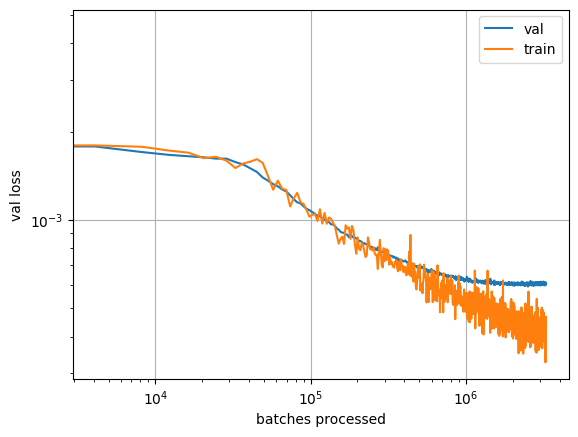

In [53]:
print(np.min(val_loss_history))
plt.plot(batch_size * 128 * np.arange(len(val_loss_history)), val_loss_history, label='val')
plt.plot(batch_size * 128 * np.arange(len(train_loss_history)), train_loss_history, label='train')
plt.xscale('log')
plt.yscale('log')
plt.ylabel('val loss')
plt.xlabel('batches processed')
plt.grid()
plt.legend()
plt.show()